# Exploritary Data Analysis On Stroke Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew,kurtosis

In [2]:
df=pd.read_csv('penguins.csv')

In [3]:
df

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [4]:
df.shape

(344, 9)

In [5]:
df.size

3096

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [7]:
df.describe()

,rowid,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,172.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,1.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,86.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,172.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,258.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,344.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [8]:
df.isna().sum()

rowid                 0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [9]:
df=df.drop(columns=['rowid'])

In [10]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


# Univariate Analysis

### Univariate Analysis on Species

In [11]:
df['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [12]:
df['species'].isna().sum()

0

In [13]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

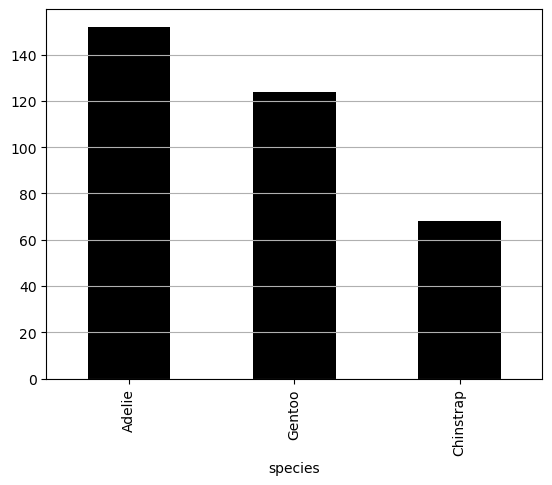

In [14]:
df['species'].value_counts().plot(kind='bar',color='black')
plt.grid(axis='y')

Text(0, 0.5, '')

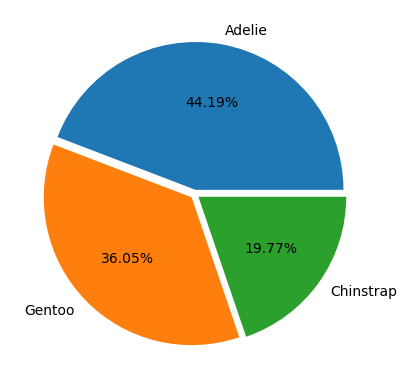

In [15]:
df['species'].value_counts().plot(kind='pie',autopct='%1.2f%%',explode=[0.03, 0.03, 0.03])
plt.ylabel("")

In [16]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


### Univariate Analysis on island

In [20]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [21]:
df['island'].isna().sum()

0

In [22]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

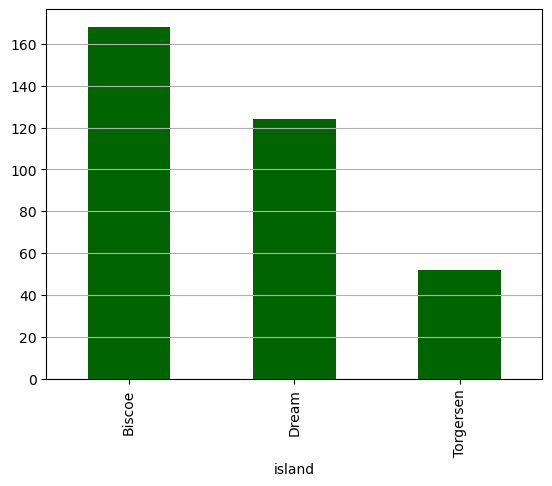

In [23]:
df['island'].value_counts().plot(kind='bar',color='darkgreen')
plt.grid(axis='y')

Text(0, 0.5, '')

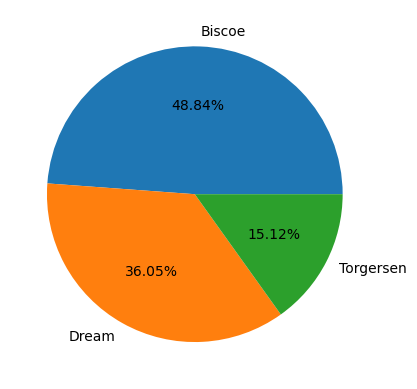

In [24]:
df['island'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.ylabel("")

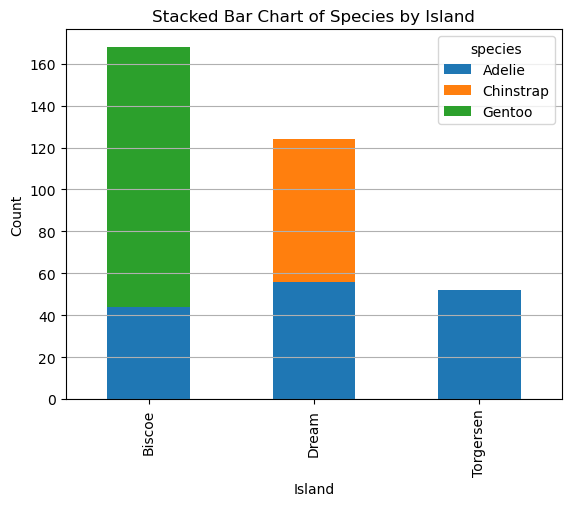

In [25]:
a=df.groupby('island')['species'].value_counts().reset_index()

pivot_df = a.pivot(index='island', columns='species', values='count').fillna(0)

pivot_df.plot(kind='bar', stacked=True)
plt.xlabel("Island")
plt.ylabel("Count")
plt.title("Stacked Bar Chart of Species by Island")
plt.grid(axis='y')
plt.show()


In [26]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


### Univariate Analysis on bill_length_mm

In [27]:
df['bill_length_mm'].unique()

array([39.1, 39.5, 40.3,  nan, 36.7, 39.3, 38.9, 39.2, 34.1, 42. , 37.8,
       41.1, 38.6, 34.6, 36.6, 38.7, 42.5, 34.4, 46. , 37.7, 35.9, 38.2,
       38.8, 35.3, 40.6, 40.5, 37.9, 37.2, 40.9, 36.4, 42.2, 37.6, 39.8,
       36.5, 40.8, 36. , 44.1, 37. , 39.6, 37.5, 42.3, 40.1, 35. , 34.5,
       41.4, 39. , 35.7, 41.3, 41.6, 35.5, 41.8, 33.5, 39.7, 45.8, 42.8,
       36.2, 42.1, 42.9, 35.1, 37.3, 36.3, 36.9, 38.3, 34. , 38.1, 33.1,
       43.2, 41. , 45.6, 42.7, 40.2, 35.2, 41.5, 38.5, 43.1, 36.8, 35.6,
       32.1, 40.7, 46.1, 50. , 48.7, 47.6, 46.5, 45.4, 46.7, 43.3, 46.8,
       49. , 45.5, 48.4, 49.3, 49.2, 46.2, 50.2, 45.1, 46.3, 44.5, 47.8,
       48.2, 47.3, 59.6, 49.1, 42.6, 44.4, 44. , 49.6, 45.3, 50.5, 43.6,
       44.9, 45.2, 46.6, 48.5, 50.1, 45. , 43.8, 50.4, 45.7, 54.3, 49.8,
       49.5, 43.5, 50.7, 47.7, 46.4, 48.6, 47.5, 51.1, 52.5, 47.4, 50.8,
       43.4, 51.3, 52.1, 52.2, 49.4, 46.9, 55.9, 47.2, 41.7, 53.4, 48.1,
       51.5, 55.1, 48.8, 49.9, 52.7, 51.7, 47. , 52

In [28]:
df['bill_length_mm'].isna().sum()

2

In [29]:
df[df['bill_length_mm'].isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [30]:
df['bill_length_mm'] = df['bill_length_mm'].fillna(
    df.groupby('species')['bill_length_mm'].transform('mean'))

In [31]:
df['bill_length_mm']=df['bill_length_mm'].round(1)

### sns.distplot(df['bill_length_mm'])

In [33]:
skew(df['bill_length_mm'])

0.05361363142655029

In [34]:
kurtosis(df['bill_length_mm'])

-0.8816597975489451

In [35]:
# KS Test on bill_length_mm

x=df['bill_length_mm']
z_val=(x - x.mean()) / x.std()
stats.kstest(z_val,'norm')

KstestResult(statistic=0.07101429089603323, pvalue=0.05927699676187648, statistic_location=-0.7732629682961585, statistic_sign=1)

In [36]:
# Andreson Test on bill_length_mm

stats.anderson(df['bill_length_mm'])

AndersonResult(statistic=3.0691941803446525, critical_values=array([0.569, 0.649, 0.778, 0.908, 1.08 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=43.91744186046511, scale=5.4540848758838205)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [37]:
df['bill_length_mm'].std()

5.4540848758838205

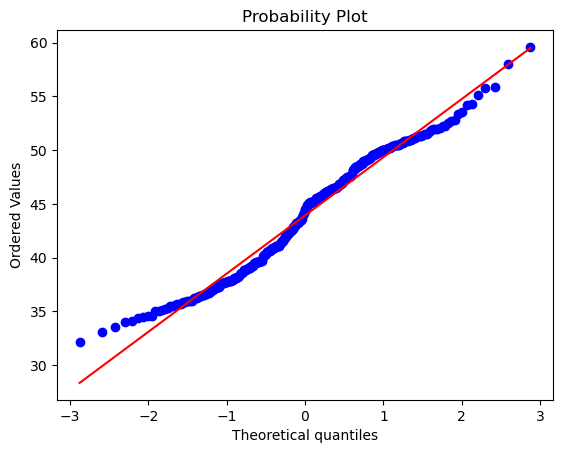

In [38]:
stats.probplot(df['bill_length_mm'],dist='norm',plot=plt)
plt.show()

Text(0, 0.5, 'Cummilative Frequency')

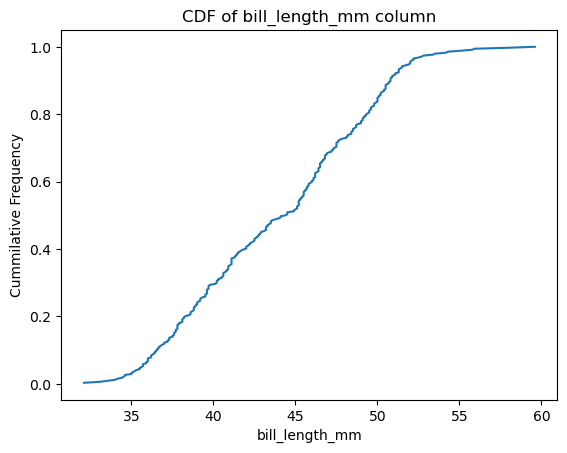

In [39]:
# cdf of bill_length_mm
sorted_val=np.sort(df['bill_length_mm'])
cdf_vals=np.arange(1,len(df['bill_length_mm'])+1)/len(sorted_val)
plt.plot(sorted_val,cdf_vals)
plt.title('CDF of bill_length_mm column')
plt.xlabel('bill_length_mm')
plt.ylabel('Cummilative Frequency')

### Univariate Analysis on bill_depth_mm

In [40]:
df['bill_depth_mm'].isna().sum()

2

In [41]:
df['bill_depth_mm'] = df['bill_depth_mm'].fillna(df.groupby('species')['bill_depth_mm'].transform('mean'))
df['bill_depth_mm']=df['bill_depth_mm'].round(1)

df['bill_depth_mm'].isna().sum()

0

C:\Users\AKASH\AppData\Local\Temp\ipykernel_23740\2050817818.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bill_depth_mm'])


<Axes: xlabel='bill_depth_mm', ylabel='Density'>

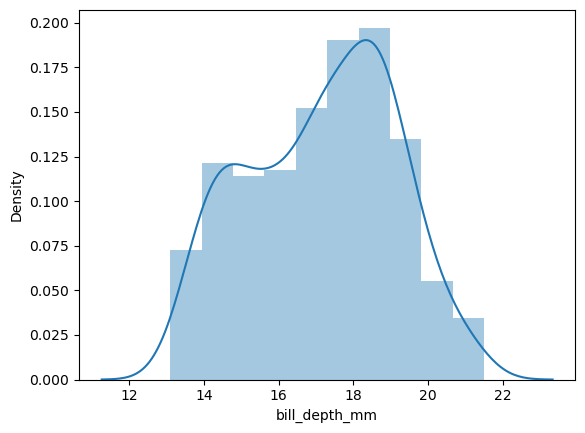

In [42]:
sns.distplot(df['bill_depth_mm'])

In [43]:
skew(df['bill_depth_mm'])

-0.14106630116949603

In [44]:
kurtosis(df['bill_depth_mm'])

-0.9139808853320663

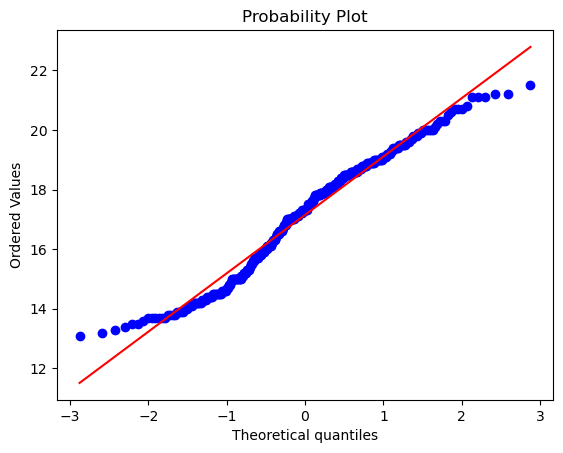

In [45]:
stats.probplot(df['bill_depth_mm'],dist='norm',plot=plt)
plt.show()

In [46]:
# KS Test on bill_depth_mm

x=df['bill_depth_mm']
z_val=(x - x.mean()) / x.std()
stats.kstest(z_val,'norm')

KstestResult(statistic=0.0799799114263745, pvalue=0.023175127741071576, statistic_location=0.3302607231311613, statistic_sign=-1)

In [47]:
# Andreson Test on bill_depth_mm

stats.anderson(df['bill_depth_mm'])

AndersonResult(statistic=2.951196442989385, critical_values=array([0.569, 0.649, 0.778, 0.908, 1.08 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=17.148255813953487, scale=1.9734232392741335)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

Text(0, 0.5, 'Cummilative Frequency')

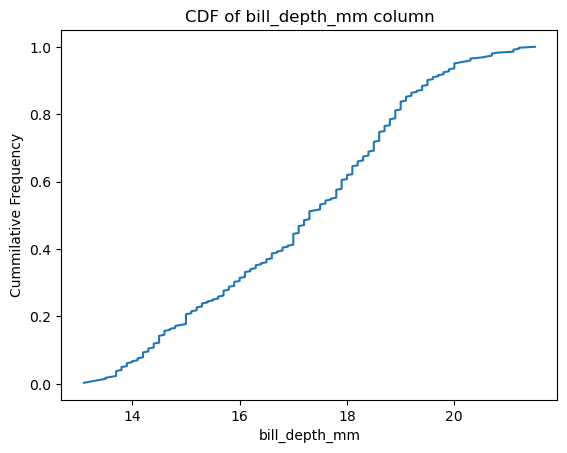

In [48]:
# cdf of bill_depth_mm
sorted_val=np.sort(df['bill_depth_mm'])
cdf_vals=np.arange(1,len(df['bill_depth_mm'])+1)/len(sorted_val)
plt.plot(sorted_val,cdf_vals)
plt.title('CDF of bill_depth_mm column')
plt.xlabel('bill_depth_mm')
plt.ylabel('Cummilative Frequency')

In [49]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,38.8,18.3,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


### Univariate Analysis on flipper_length_mm

In [50]:
df['flipper_length_mm'].unique()

array([181., 186., 195.,  nan, 193., 190., 180., 182., 191., 198., 185.,
       197., 184., 194., 174., 189., 187., 183., 172., 178., 188., 196.,
       179., 200., 192., 202., 205., 208., 203., 199., 176., 210., 201.,
       211., 230., 218., 215., 219., 209., 214., 216., 213., 217., 221.,
       222., 220., 207., 225., 224., 231., 229., 223., 212., 228., 226.,
       206.])

In [51]:
df['flipper_length_mm'].isna().sum()

2

In [52]:
df['flipper_length_mm']=df['flipper_length_mm'].fillna(df.groupby('species')['flipper_length_mm'].transform('mean'))

df['flipper_length_mm']=df['flipper_length_mm'].round(1)

#### Statistical Univariate Analysis on flipper_length_mm

In [53]:
df['flipper_length_mm'].mean()

200.93081395348835

In [54]:
df['flipper_length_mm'].std()

14.060551413123447

In [55]:
df['flipper_length_mm'].median()

197.0

In [56]:
df['flipper_length_mm'].min()

172.0

In [57]:
df['flipper_length_mm'].max()

231.0

In [58]:
percentiles=[0,10,25,50,75,90,95,99,100]

for i in percentiles:
    percentile_values=np.percentile(df['flipper_length_mm'],i)
    print(f'{i}th Percentile Value : {percentile_values}')

0th Percentile Value : 172.0
10th Percentile Value : 185.0
25th Percentile Value : 190.0
50th Percentile Value : 197.0
75th Percentile Value : 213.25
90th Percentile Value : 220.7
95th Percentile Value : 225.0
99th Percentile Value : 230.0
100th Percentile Value : 231.0


#### Graphical Univariate Analysis on flipper_length_mm

C:\Users\AKASH\AppData\Local\Temp\ipykernel_23740\2376148029.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['flipper_length_mm'])


<Axes: xlabel='flipper_length_mm', ylabel='Density'>

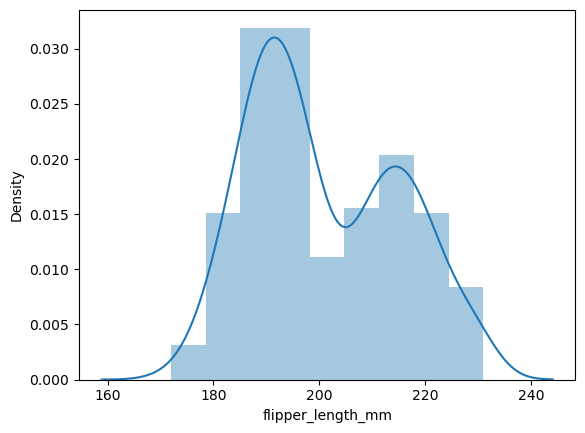

In [59]:
sns.distplot(df['flipper_length_mm'])

In [60]:
skew(df['flipper_length_mm'])

0.34207381991748625

In [61]:
kurtosis(df['flipper_length_mm'])

-0.993747441558638

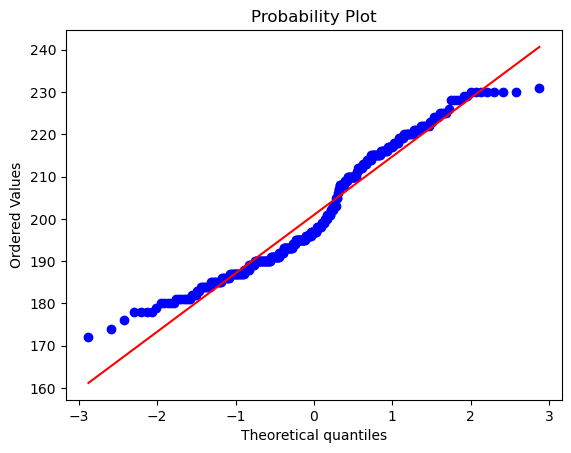

In [62]:
stats.probplot(df['flipper_length_mm'],dist='norm',plot=plt)
plt.show()

In [63]:
# KS Test on bill_depth_mm

x=df['flipper_length_mm']
z_val=(x - x.mean()) / x.std()
stats.kstest(z_val,'norm')

KstestResult(statistic=0.12462859473160937, pvalue=4.080274012174981e-05, statistic_location=-0.27956328581961015, statistic_sign=1)

In [64]:
# Andreson Test on bill_depth_mm

stats.anderson(df['flipper_length_mm'])

AndersonResult(statistic=6.565267977062149, critical_values=array([0.569, 0.649, 0.778, 0.908, 1.08 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=200.93081395348835, scale=14.060551413123447)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

<Axes: ylabel='flipper_length_mm'>

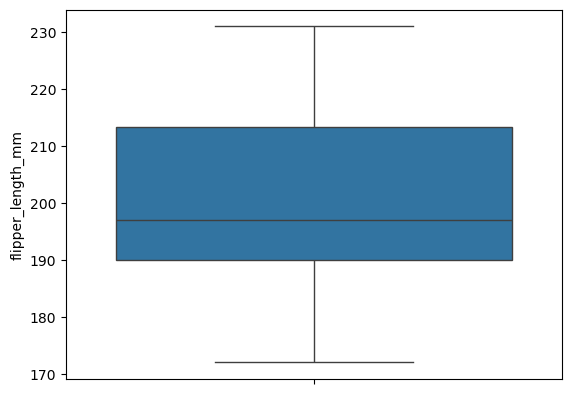

In [65]:
sns.boxplot(df['flipper_length_mm'])

Text(0, 0.5, 'Cummilative Frequency')

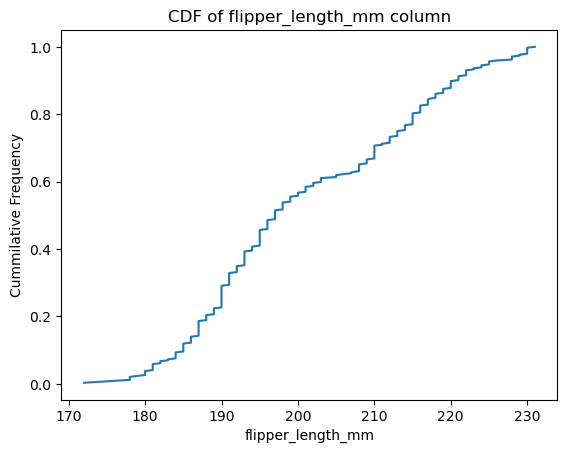

In [66]:
# cdf of flipper_length_mm

sorted_val=np.sort(df['flipper_length_mm'])
cdf_vals=np.arange(1,len(df['flipper_length_mm'])+1)/len(sorted_val)
plt.plot(sorted_val,cdf_vals)
plt.title('CDF of flipper_length_mm column')
plt.xlabel('flipper_length_mm')
plt.ylabel('Cummilative Frequency')

## Univariate Analysis on body_mass_g

In [67]:
df['body_mass_g'].unique()

array([3750., 3800., 3250.,   nan, 3450., 3650., 3625., 4675., 3475.,
       4250., 3300., 3700., 3200., 4400., 4500., 3325., 4200., 3400.,
       3600., 3950., 3550., 3150., 3900., 4150., 4650., 3100., 3000.,
       4600., 3425., 2975., 3500., 4300., 4050., 2900., 2850., 3350.,
       4100., 3050., 4450., 4000., 4700., 4350., 3725., 4725., 3075.,
       2925., 3175., 4775., 3825., 4275., 4075., 3775., 3875., 3275.,
       4475., 3975., 5700., 5400., 4550., 4800., 5200., 5150., 5550.,
       5850., 6300., 5350., 5000., 5050., 5100., 5650., 5250., 6050.,
       4950., 4750., 4900., 5300., 4850., 5800., 6000., 5950., 4625.,
       5450., 5600., 4875., 4925., 4975., 5500., 4575., 4375., 5750.,
       3525., 3575., 3850., 2700., 3675.])

In [68]:
df['body_mass_g'].isna().sum()

2

In [69]:
df['body_mass_g']=df['body_mass_g'].fillna(df.groupby('species')['body_mass_g'].transform('mean'))
df['body_mass_g']=df['body_mass_g'].round(1)
df['body_mass_g'].isna().sum()

0

#### statistical Univariate Analysis on flipper_length_mm

In [70]:
df['body_mass_g'].mean()

4202.839244186046

In [71]:
df['body_mass_g'].std()

801.4612263713614

In [72]:
df['body_mass_g'].median()

4050.0

In [73]:
df['body_mass_g'].min()

2700.0

In [74]:
df['body_mass_g'].max()

6300.0

In [75]:
percentiles=[0,10,25,50,75,90,95,99,100]

for i in percentiles:
    percentile_values=np.percentile(df['body_mass_g'],i)
    print(f'{i}th Percentile Value : {percentile_values}')

0th Percentile Value : 2700.0
10th Percentile Value : 3300.0
25th Percentile Value : 3550.0
50th Percentile Value : 4050.0
75th Percentile Value : 4756.25
90th Percentile Value : 5400.0
95th Percentile Value : 5650.0
99th Percentile Value : 5978.5
100th Percentile Value : 6300.0


#### Graphical Univariate Analysis on flipper_length_mm

C:\Users\AKASH\AppData\Local\Temp\ipykernel_23740\2151326810.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['body_mass_g'])


<Axes: xlabel='body_mass_g', ylabel='Density'>

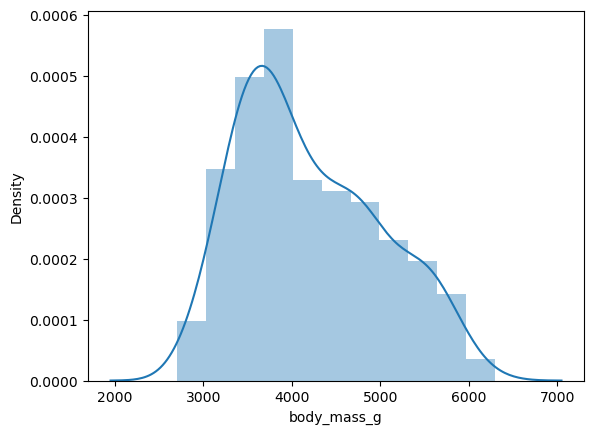

In [76]:
sns.distplot(df['body_mass_g'])

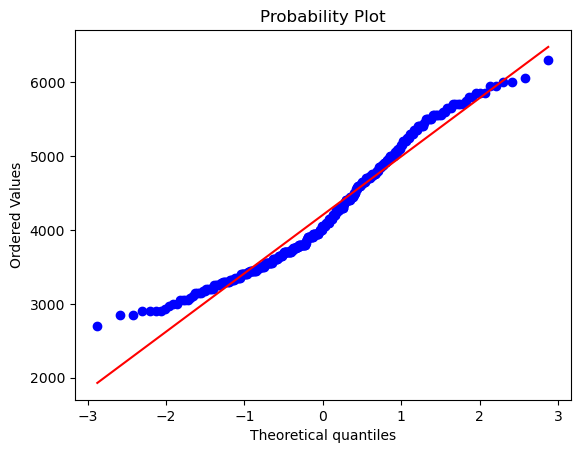

In [77]:
stats.probplot(df['body_mass_g'],dist='norm',plot=plt)
plt.show()

In [78]:
skew(df['body_mass_g'])

0.4653991801023269

In [79]:
kurtosis(df['body_mass_g'])

-0.7319168282206272

In [80]:
#lets apply kstest on  body_mass_g

z_val=(df['body_mass_g']-np.mean(df['body_mass_g']))/np.std(df['body_mass_g'])
stats.kstest(z_val,'norm')

KstestResult(statistic=0.10543620959360461, pvalue=0.000876339299497243, statistic_location=-0.503363148139618, statistic_sign=1)

In [81]:
#lets apply ADtest on  body_mass_g

stats.anderson(df['body_mass_g'])

AndersonResult(statistic=4.589279331458101, critical_values=array([0.569, 0.649, 0.778, 0.908, 1.08 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=4202.839244186046, scale=801.4612263713614)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

<Axes: ylabel='body_mass_g'>

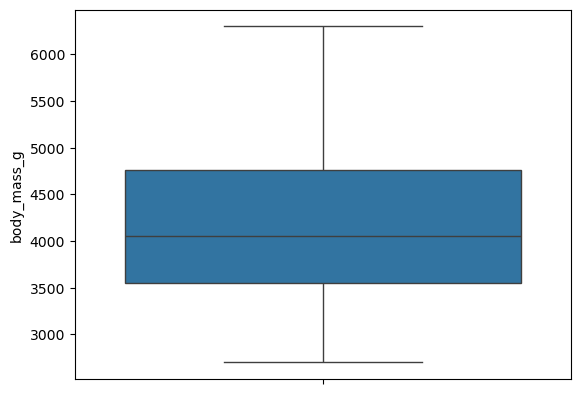

In [82]:
sns.boxplot(df['body_mass_g'])

Text(0, 0.5, 'Cummilative Frequency')

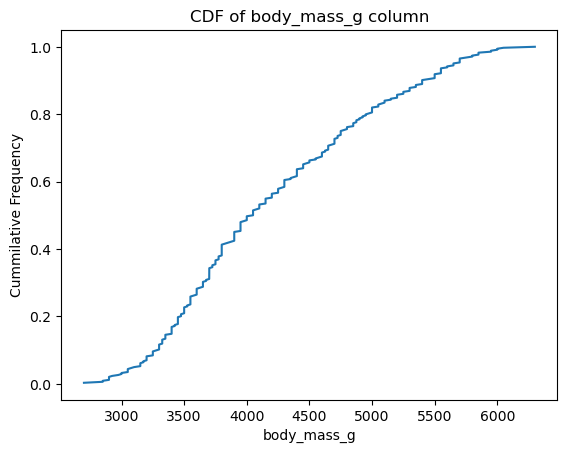

In [83]:
sorted_val=df['body_mass_g'].sort_values()
cdf_values=np.arange(1,len(sorted_val)+1)/len(sorted_val)

plt.plot(sorted_val,cdf_values)
plt.title('CDF of body_mass_g column')
plt.xlabel('body_mass_g')
plt.ylabel('Cummilative Frequency')

## Univariate Analysis on sex

In [84]:
df['sex'].unique()

array(['male', 'female', nan], dtype=object)

In [85]:
df['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

In [86]:
df['sex'].isna().sum()

11

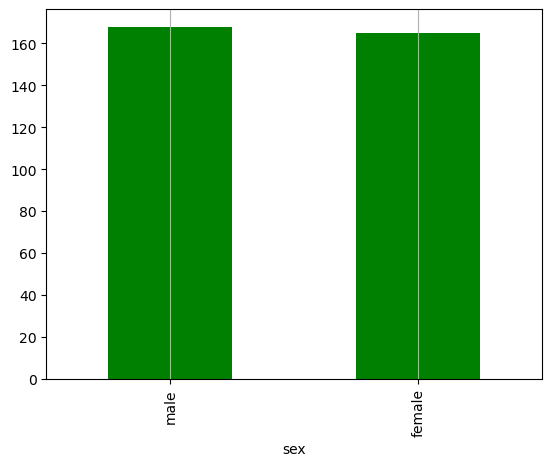

In [87]:
df['sex'].value_counts().plot(kind='bar',color='g')
plt.grid(axis='x')

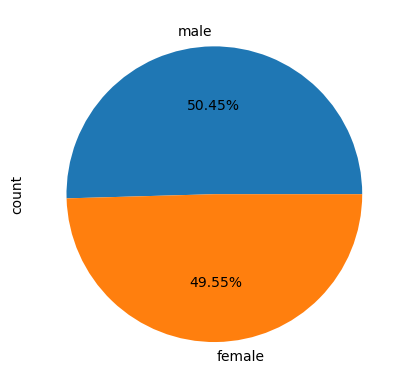

In [88]:
df['sex'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.grid(axis='x')

<Axes: xlabel='species'>

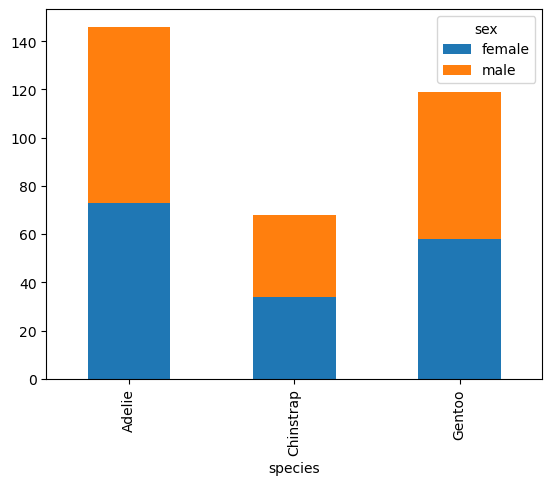

In [89]:
a=df.groupby('species')['sex'].value_counts().reset_index()

pivot_df = a.pivot(index='species', columns='sex', values='count').fillna(0)

pivot_df.plot(kind='bar', stacked=True)

array([<Axes: ylabel='female'>, <Axes: ylabel='male'>], dtype=object)

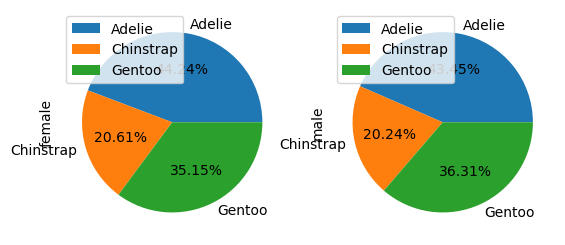

In [90]:
pivot_df.plot(kind='pie', subplots=True,autopct='%1.2f%%')

In [91]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,38.8,18.3,190.0,3700.7,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


## Univariate Analysis on year

In [92]:
df['year'].unique()

array([2007, 2008, 2009], dtype=int64)

In [93]:
df['year'].isna().sum()

0

In [94]:
df['year'].value_counts()

year
2009    120
2008    114
2007    110
Name: count, dtype: int64

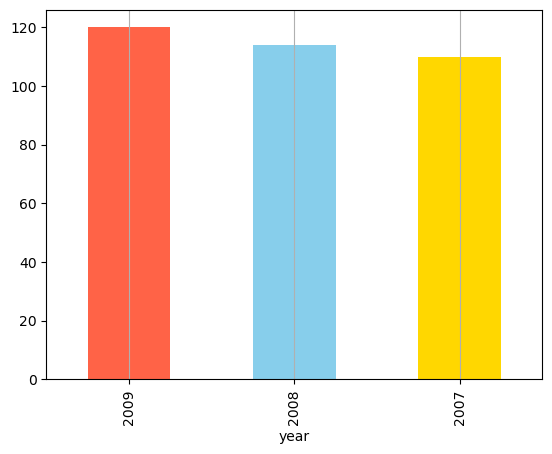

In [95]:
df['year'].value_counts().plot(kind='bar',color=['tomato', 'skyblue', 'gold', 'violet'])
plt.grid(axis='x')

<Axes: xlabel='species'>

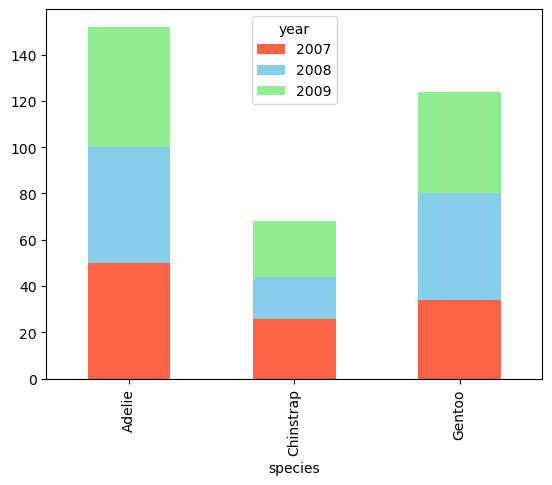

In [96]:
a=df.groupby('species')['year'].value_counts().reset_index()

pivot_df = a.pivot(index='species', columns='year', values='count').fillna(0)

pivot_df.plot(kind='bar', stacked=True,color=['tomato', 'skyblue', 'lightgreen', 'violet'])

# Bivariate Analysis

In [97]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,38.8,18.3,190.0,3700.7,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


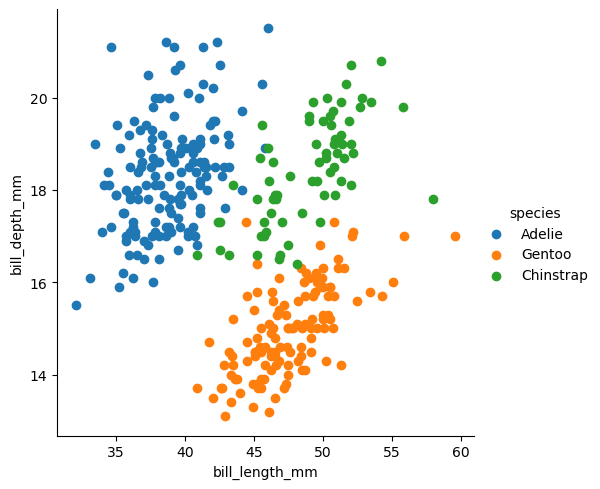

In [98]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'bill_length_mm','bill_depth_mm').add_legend()

In [99]:
stats.spearmanr(df['bill_length_mm'],df['bill_depth_mm'])

SignificanceResult(statistic=-0.22405696297864136, pvalue=2.7413517643462213e-05)

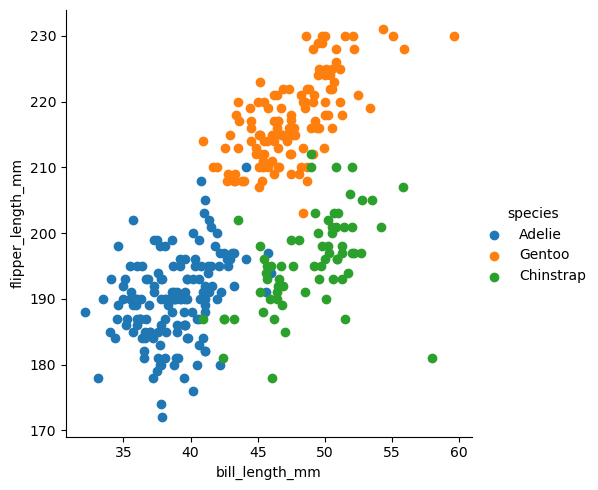

In [100]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'bill_length_mm','flipper_length_mm').add_legend()

In [101]:
stats.spearmanr(df['bill_length_mm'],df['flipper_length_mm'])

SignificanceResult(statistic=0.6741384430050964, pvalue=6.32917252911947e-47)

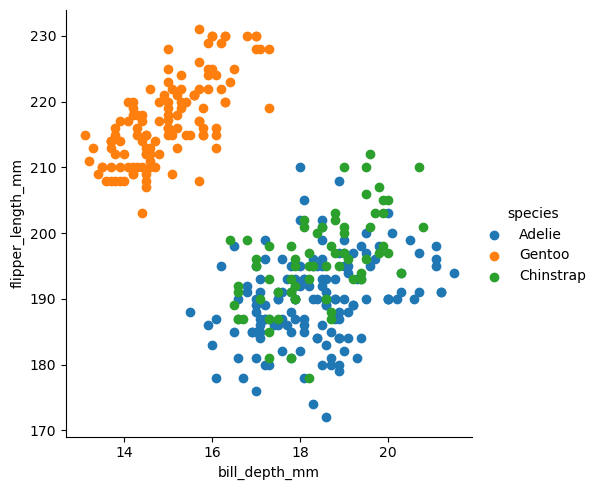

In [102]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'bill_depth_mm','flipper_length_mm').add_legend()

In [103]:
stats.spearmanr(df['bill_depth_mm'],df['flipper_length_mm'])

SignificanceResult(statistic=-0.5245721896163781, pvalue=1.0263849619867884e-25)

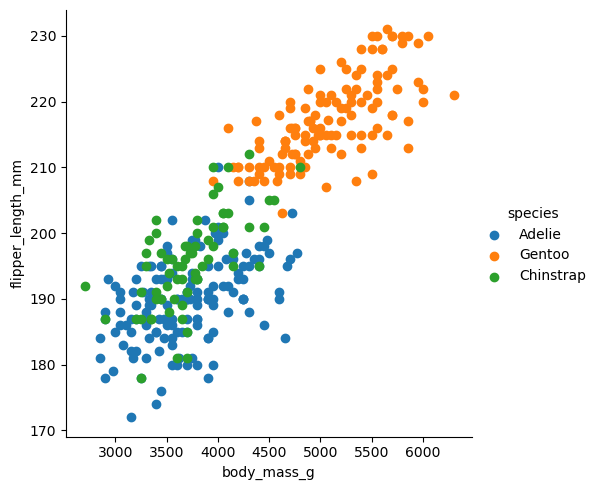

In [104]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'body_mass_g','flipper_length_mm').add_legend()

In [107]:
stats.spearmanr(df['body_mass_g'],df['flipper_length_mm'])

SignificanceResult(statistic=0.840575099947001, pvalue=4.504724788933093e-93)

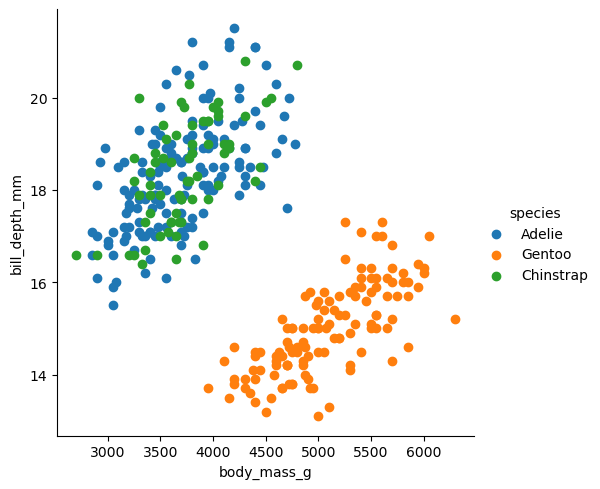

In [105]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'body_mass_g','bill_depth_mm').add_legend()

In [108]:
stats.spearmanr(df['body_mass_g'],df['bill_depth_mm'])

SignificanceResult(statistic=-0.43413224816184776, pvalue=3.038924179682037e-17)

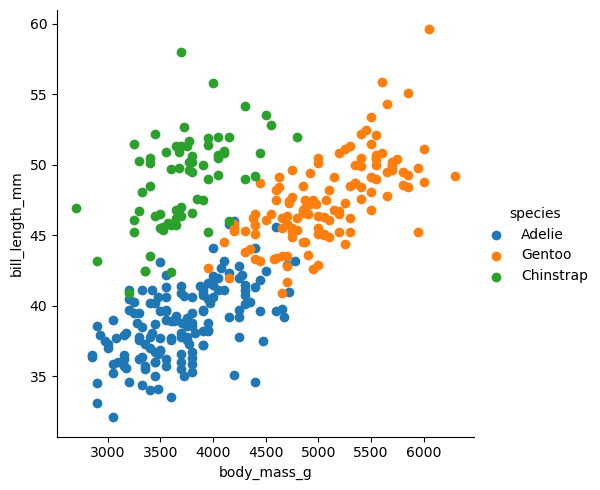

In [110]:
sns.FacetGrid(df,hue='species',height=5).map(plt.scatter,'body_mass_g','bill_length_mm').add_legend()

In [111]:
stats.spearmanr(df['body_mass_g'],df['bill_length_mm'])

SignificanceResult(statistic=0.5853693580277541, pvalue=5.095623595870456e-33)

In [112]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,38.8,18.3,190.0,3700.7,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


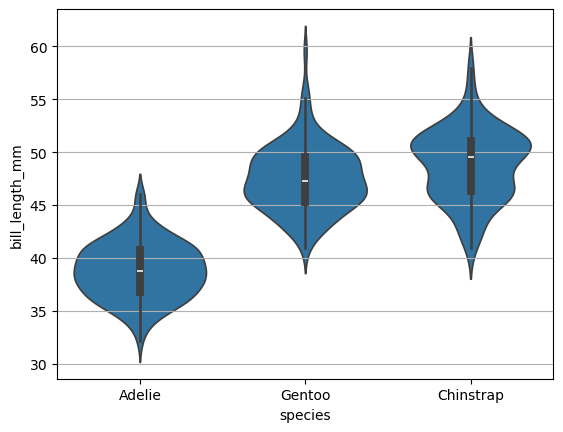

In [118]:
sns.violinplot(df,x='species',y='bill_length_mm')
plt.grid(axis='y')

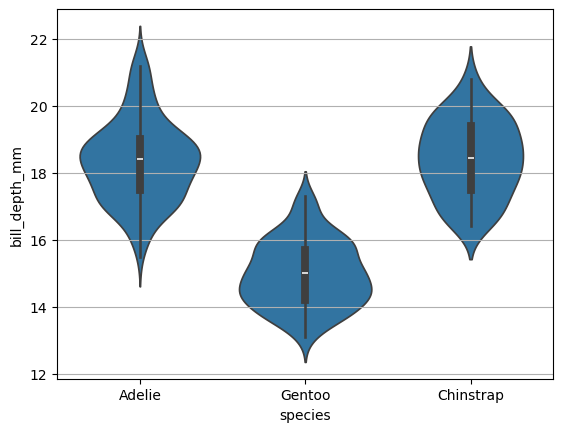

In [119]:
sns.violinplot(df,x='species',y='bill_depth_mm')
plt.grid(axis='y')

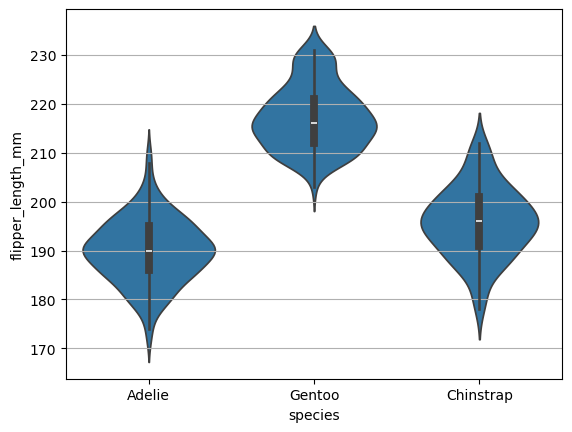

In [120]:
sns.violinplot(df,x='species',y='flipper_length_mm')
plt.grid(axis='y')

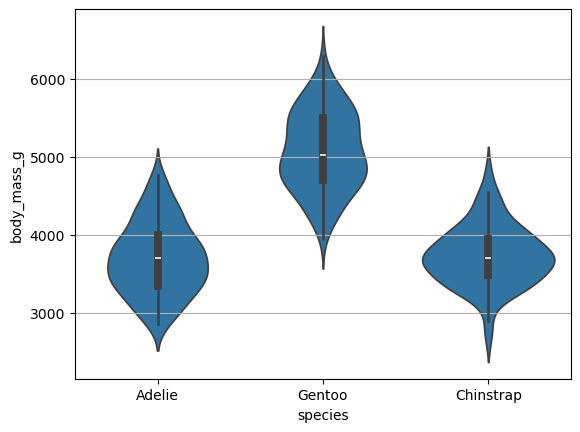

In [121]:
sns.violinplot(df,x='species',y='body_mass_g')
plt.grid(axis='y')

# Multivariate Analysis

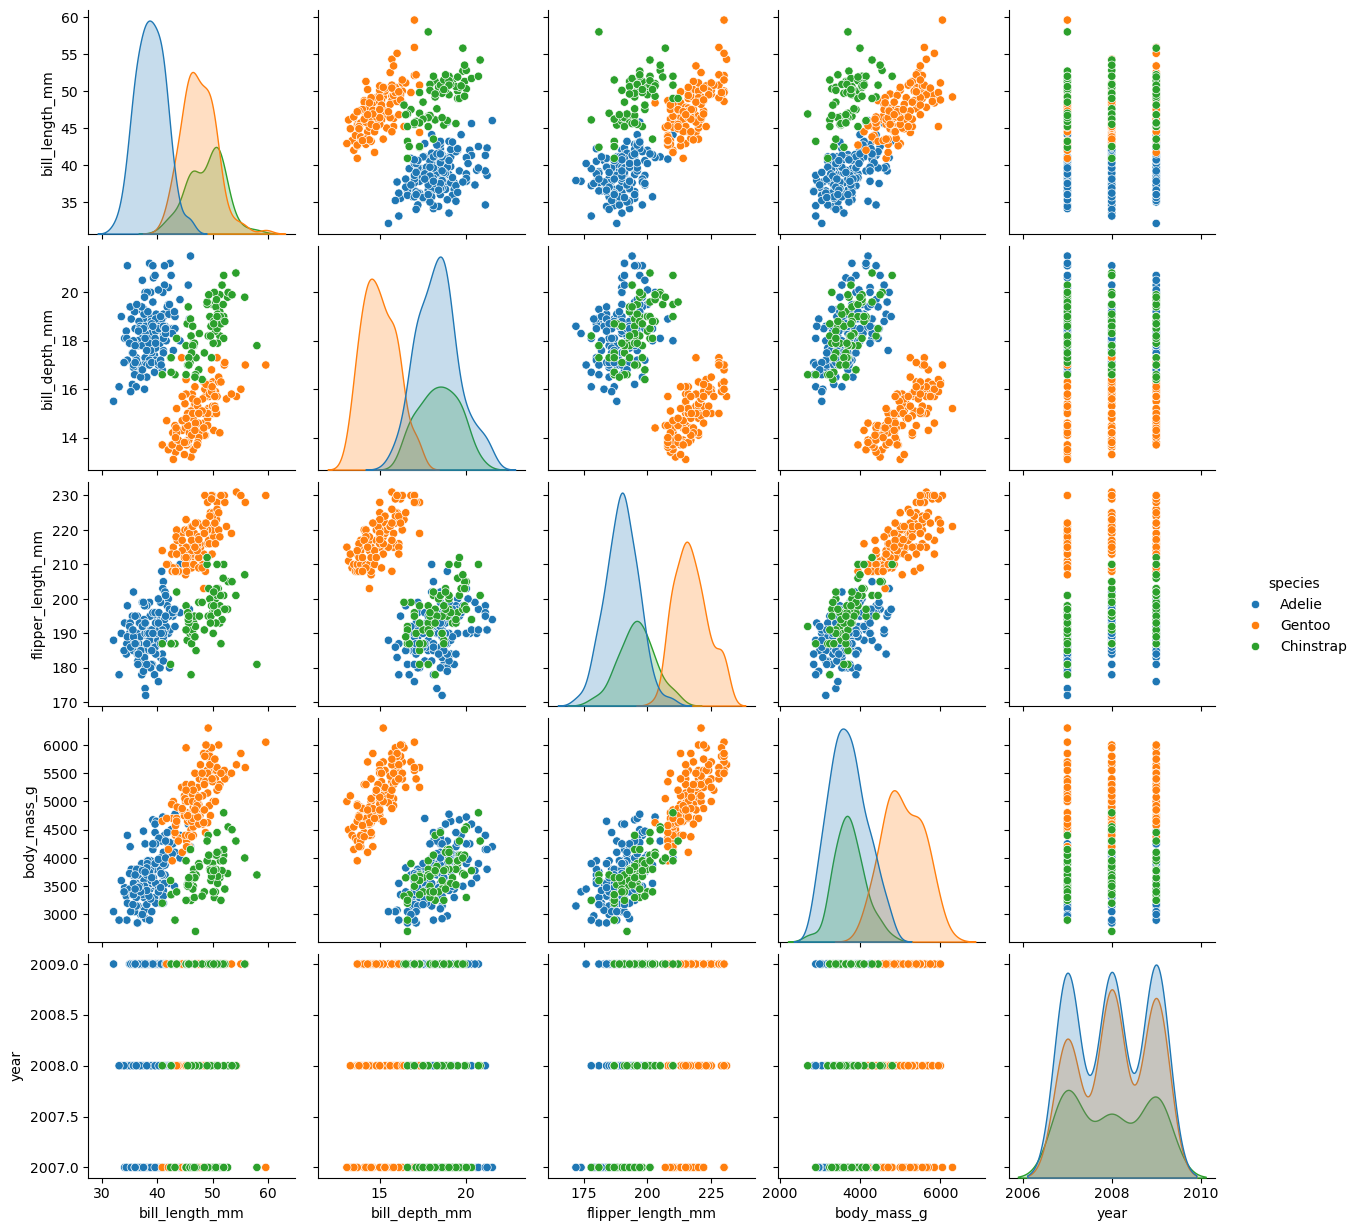

In [123]:
sns.pairplot(df,hue='species')

<Axes: >

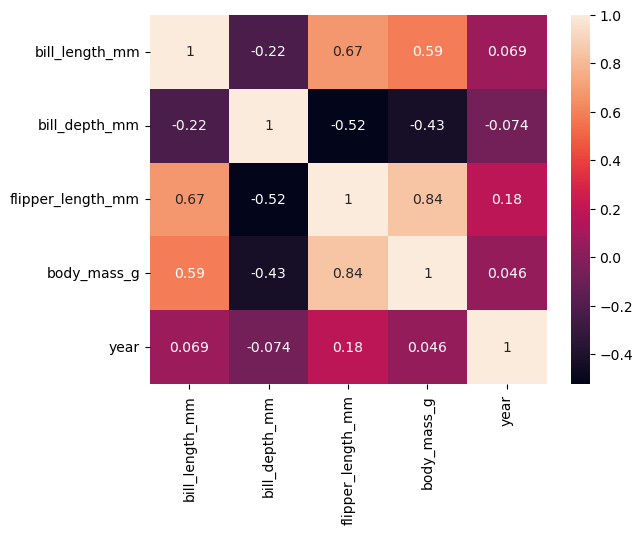

In [126]:
sns.heatmap(df.select_dtypes(include=['int','float']).corr(method='spearman'),annot=True)